In [50]:
import pandas as pd

# 1. Load the dataset with low_memory=False to handle mixed types warning
df = pd.read_csv('SSC_merged_no_blank_keys.csv', low_memory=False)

loss_indicators = [
    'Yes/Oui', 
    "Already lost sense of smell/Déjà perdu l'odorat"
]


# 2. Define the mapping using the EXACT raw strings from your index list
column_mapping = {
    "Project key": "project_key",
    # Demographic
    "Age at study visit (automatic calculated field):    Âge au moment de la visite d'étude (champ calculé automatiquement):": "age_at_visit",
    "1. Gender/Genre:": "gender",
    # Clinical
    "What is the current duration of disease? (years)    Quelle est la durée actuelle de la maladie? (years)": "disease_duration",
    "What is the age at diagnosis? (years)    Quel est l'âge du diagnostic? (années)": "age_at_diagnosis",
    "9. What symptoms are currently present?    9. Quels sont les symptômes présents actuellement?": "current_symptoms",
    "8. When the symptoms began, did the symptoms present on one side or both sides of your body?    8. Les symptômes sont-ils apparus d'un seul côté ou des deux côté de votre corps?": "symptom_laterality",
    "8. Do you feel or have people told you that your sense of smell is getting worse?    8. Avez-vous remarqué ou vous a-t-on fait remarquer que vous aviez une perte d'odorat?": "smell_loss",
    "6. What is your dominant hand?    6. Quelle est votre main dominante?": "dominant_hand",
    "20. Do you exercise on a regular basis?    20. Faites-vous de l\'exercice régulièrement?": "exercise",
    "23. Do you currently drink coffee?    23. Buvez-vous du café régulièrement?": "coffee_drinker",
    # MoCA
    "TOTAL SCORE (make sure to include extra point for 12 years or less of education):    SCORE TOTAL (assurez-vous d'inclure un point supplémentaire pour 12 ans ou moins d'éducation) :.x": "moca_total",
    # BDI-II
    "BDI-II Total Score": "bdi_total",
    # MBI-C (Note: using the version with the .x suffix found in your list)
    "MBI-C Grand Total.x": "mbi_total",
    # EHI
    "EHI Handedness Score": "ehi_score",
    # Outcome
    "Enrolment Group:    Groupe d'inscription:": "outcome"
}


# 3. Filter and Rename
# We use a list comprehension to ensure we only grab keys that actually exist in the dataframe
available_cols = [col for col in column_mapping.keys() if col in df.columns]
df_filtered = df[available_cols].copy()
df_filtered.rename(columns=column_mapping, inplace=True)

# Create the binary variable
# .astype(int) converts True/False to 1/0
df_filtered['smell_loss'] = df_filtered['smell_loss'].isin(loss_indicators).astype(int)

# 4. Clean the Outcome Variable
# This removes leading/trailing spaces and ensures consistent categories
df_filtered['outcome'] = df_filtered['outcome'].str.strip()

# 5. Review the results
print(f"Successfully extracted {len(df_filtered.columns)} variables.")
print(df_filtered['outcome'].value_counts())
print(df_filtered.head())

Successfully extracted 16 variables.
outcome
PD (Parkinson's Disease)/(Maladie de Parkinson)        2852
Healthy control/Contrôle                                410
AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)     171
Name: count, dtype: int64
  project_key  age_at_visit          gender  disease_duration  \
0     SSC0001          50.0   Male/Masculin              14.0   
1     SSC0002          65.0  Female/Féminin              11.3   
2     SSC0003          66.0   Male/Masculin              19.6   
3     SSC0004          53.0   Male/Masculin               9.8   
4     SSC0005          52.0   Male/Masculin               9.6   

   age_at_diagnosis                                   current_symptoms  \
0              45.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
1              62.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
2              54.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
3              50.0  Tremor/Tremblements,Muscle stiffness (Rig

In [51]:
import pandas as pd
import numpy as np
%pip install jinja2

# 1. Define Groups and Columns
# Ensure 'outcome' is clean
#df_filtered['outcome'] = df_filtered['outcome'].fillna('Unknown')
unique_groups = [g for g in df_filtered['outcome'].unique() if g != 'Unknown']

numeric_cols = ['age_at_visit', 'age_at_diagnosis', 'disease_duration', 'moca_total', 'bdi_total', 'mbi_total', 'ehi_score']
categorical_cols = ['gender', 'smell_loss', 'dominant_hand', "exercise", "coffee_drinker"]

def get_stats(df, label):
    """Calculates Mean (SD) or Count (%) and handles empty/NaN values."""
    stats = {}
    n = len(df)
    stats['Sample Size (n)'] = int(n)
    
    # Numeric Logic
    for col in numeric_cols:
        if col in df.columns:
            val = df[col].dropna()
            if len(val) > 0:
                stats[col] = f"{val.mean():.2f} ({val.std():.2f})"
            else:
                stats[col] = "---" # Cleaner than NaN/empty
                
    # Categorical Logic (showing top result for brevity)
    for col in categorical_cols:
        if col in df.columns:
            counts = df[col].value_counts()
            if not counts.empty:
                top_cat = counts.index[0]
                count = counts.iloc[0]
                perc = (count / n) * 100
                stats[f"{col} ({top_cat})"] = f"{count} ({perc:.1f}%)"
            else:
                stats[f"{col}"] = "---"
                
    return pd.Series(stats, name=label)

# 2. Generate Columns
# Generate 'Overall' first
overall_col = get_stats(df_filtered, 'Overall')

# Generate individual group columns
group_cols = [get_stats(df_filtered[df_filtered['outcome'] == g], g) for g in unique_groups]

# 3. Concatenate and Clean
table_1 = pd.concat([overall_col] + group_cols, axis=1)

# FINAL FIX: Remove any rows that are entirely "---" or empty across all columns
table_1 = table_1.replace("---", np.nan).dropna(how='all').fillna("---")

import pandas as pd
import numpy as np

# 1. Generate the table using the logic from our previous step
# (Assuming 'table_1' is the DataFrame we built)

def format_as_kable(df):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]}
    ]).set_caption("Table 1: Clinical Characteristics and Demographics") \
      .set_table_attributes('style="border-collapse: collapse; width: 100%;"')

# Display in Notebook
formatted_table = format_as_kable(table_1)
formatted_table


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_92273/438414767.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_1 = table_1.replace("---", np.nan).dropna(how='all').fillna("---")


,Overall,PD (Parkinson's Disease)/(Maladie de Parkinson),Healthy control/Contrôle,AP (Atypical Parkinsonism)/(Parkinsonisme Atypique),nan
Sample Size (n),3541,2852,410,171,0.000000
age_at_visit,66.20 (10.04),66.59 (9.59),62.54 (12.22),66.64 (11.71),---
age_at_diagnosis,60.73 (10.42),60.60 (10.25),---,63.26 (12.98),---
disease_duration,9.64 (6.01),9.83 (5.98),---,6.05 (5.50),---
moca_total,26.70 (2.71),26.58 (2.53),27.78 (3.15),22.00 (nan),---
bdi_total,9.65 (7.53),9.66 (7.35),6.24 (5.93),16.76 (10.45),---
mbi_total,0.94 (4.22),0.93 (4.09),0.33 (2.01),3.24 (8.62),---
ehi_score,0.71 (0.46),0.72 (0.44),0.66 (0.56),0.72 (0.50),---
gender (Male/Masculin),1804 (50.9%),1612 (56.5%),---,78 (45.6%),---
smell_loss (0),2385 (67.4%),1762 (61.8%),385 (93.9%),135 (78.9%),---


# Models

### Cross Validation

Three class classification directly, PD, PD-plus and healthy controls


 MODEL: Logistic Regression 
 5-Fold CV Macro F1: 0.433 (+/- 0.014)
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.12      0.44      0.18        34
                           Healthy control/Contrôle       0.34      1.00      0.51        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.97      0.54      0.69       571

                                           accuracy                           0.59       687
                                          macro avg       0.48      0.66      0.46       687
                                       weighted avg       0.85      0.59      0.65       687


 MODEL: Random Forest 
 5-Fold CV Macro F1: 0.476 (+/- 0.023)
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.10      0.29      0.15        34
                           

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_92273/1250070507.py:101: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


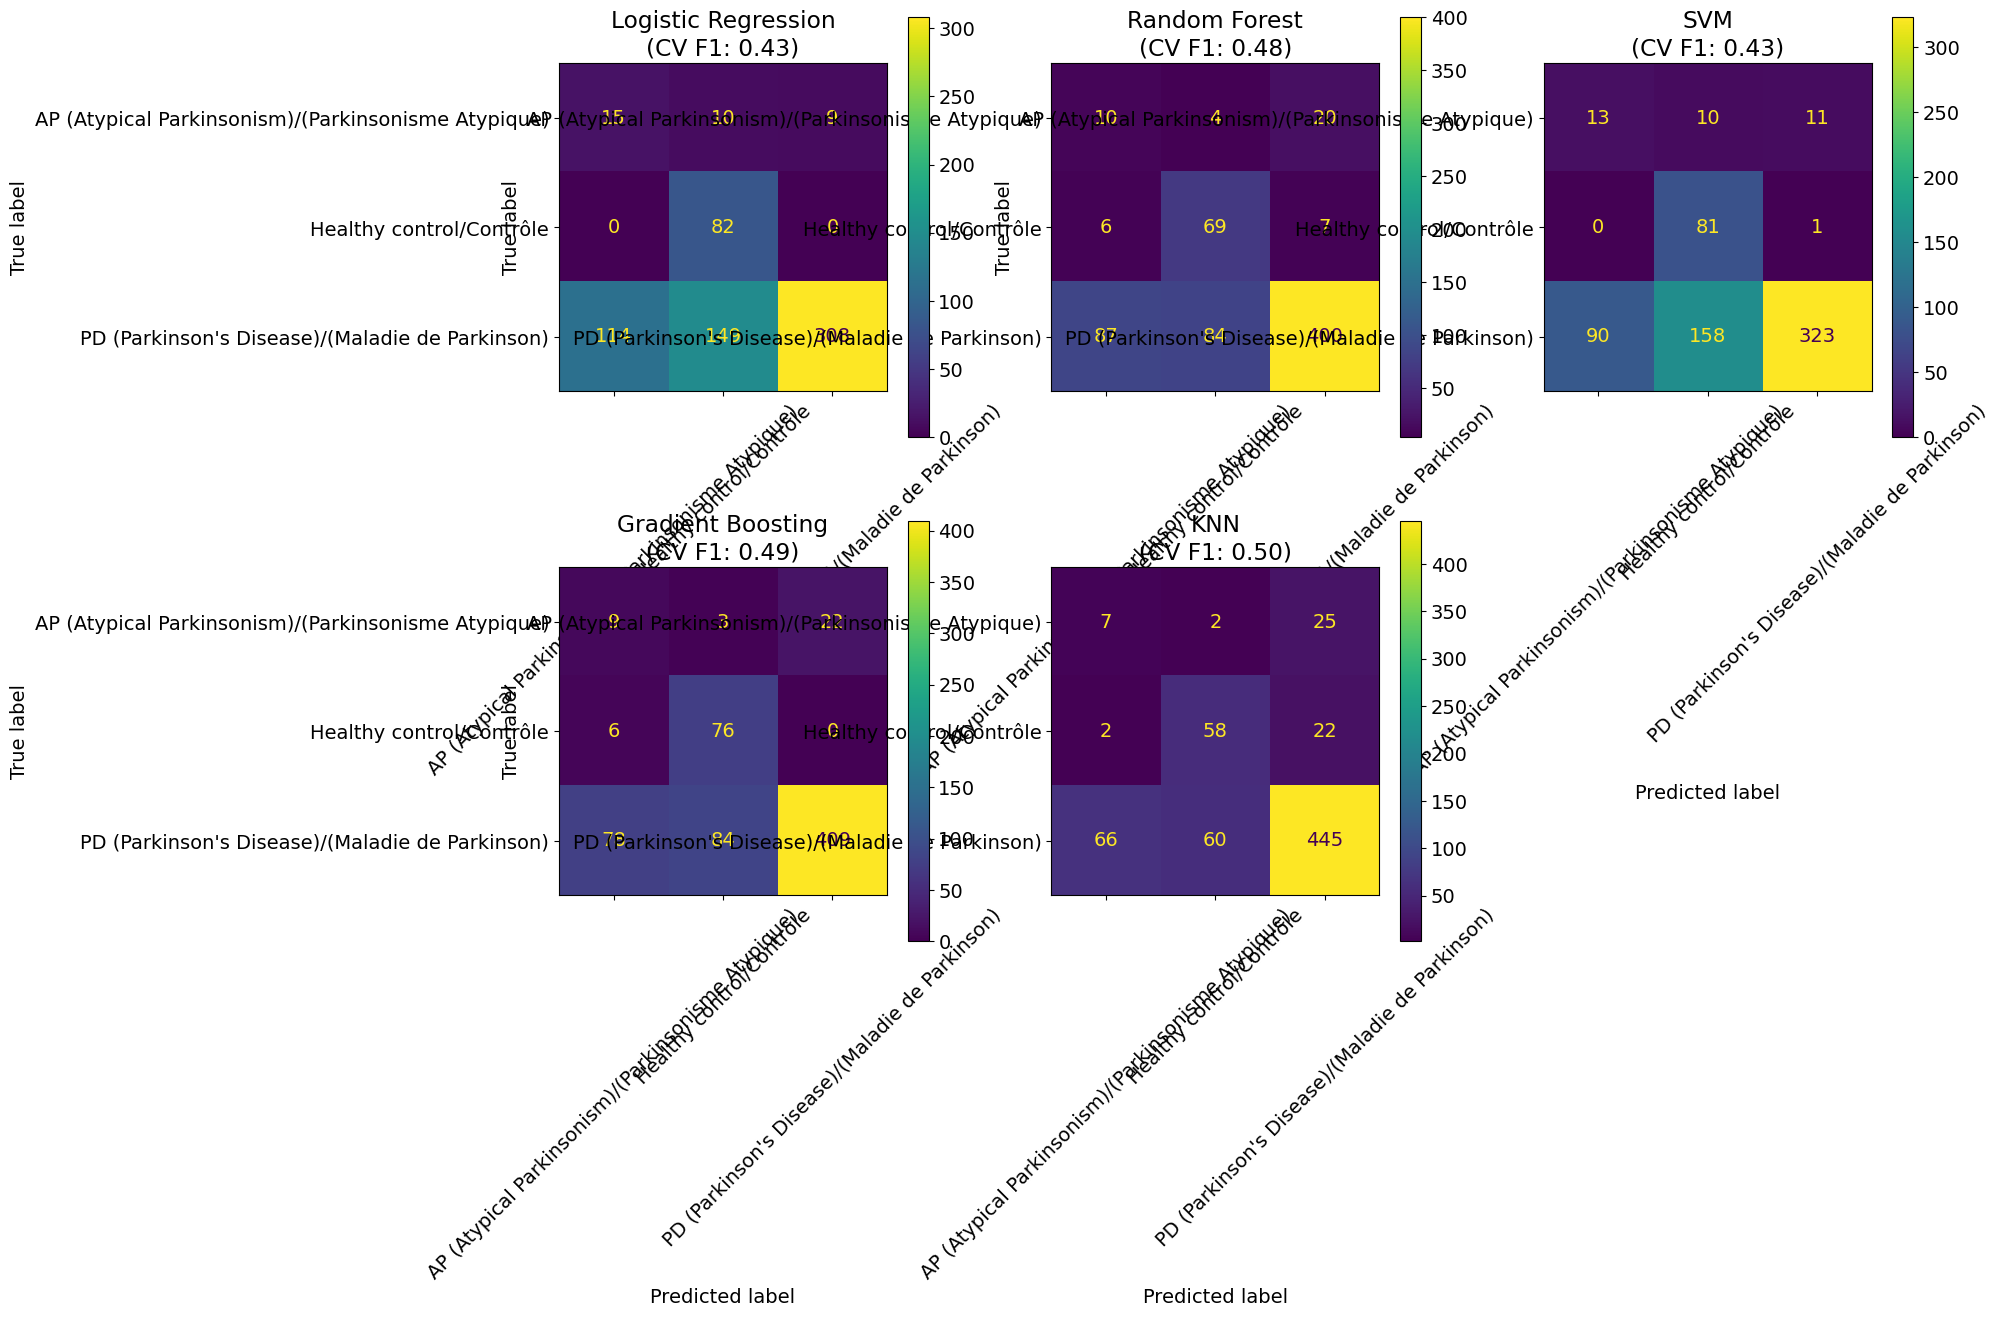

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# imblearn is required for SMOTE within a pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- 1. Clean Data & Encode Target ---
df_ml = df_filtered.dropna(subset=['outcome']).copy()
df_ml['outcome'] = df_ml['outcome'].str.strip()

le = LabelEncoder()
y = le.fit_transform(df_ml['outcome'])
X = df_ml.drop(columns=['outcome', 'project_key'])

# --- 2. Define Feature Groups ---
numeric_features = ['age_at_visit', 
                    'moca_total', 'bdi_total', 'mbi_total', 'ehi_score']
categorical_features = ['gender', 'smell_loss', 'dominant_hand', 'symptom_laterality']

# --- 3. Preprocessing Transformers ---
num_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

# --- 4. Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# --- 5. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# --- 6. Execution with SMOTE and Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a 2x3 grid to fit 5 models comfortably
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten to 1D array for easier indexing in the loop

for i, (name, clf) in enumerate(models.items()):
    pipeline = ImbPipeline(steps=[
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])
    
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n" + "="*45)
    print(f" MODEL: {name} ")
    print(f" 5-Fold CV Macro F1: {cv_results.mean():.3f} (+/- {cv_results.std():.3f})")
    print("="*45)
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        display_labels=le.classes_, 
        cmap='viridis', 
        ax=axes[i], 
        xticks_rotation=45
    )
    axes[i].set_title(f"{name}\n(CV F1: {cv_results.mean():.2f})")

# Remove the empty 6th subplot
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

This first classifies patietns into healthy or with parkinsonism. Then it takes the ones with parkinsonism and classifies them into PD and PD-plus


--- Starting Task 1: Healthy vs. Parkinsonism ---
Finished Tuning: Logistic Regression
Finished Tuning: Random Forest
Finished Tuning: SVM
Finished Tuning: Gradient Boosting
Finished Tuning: KNN


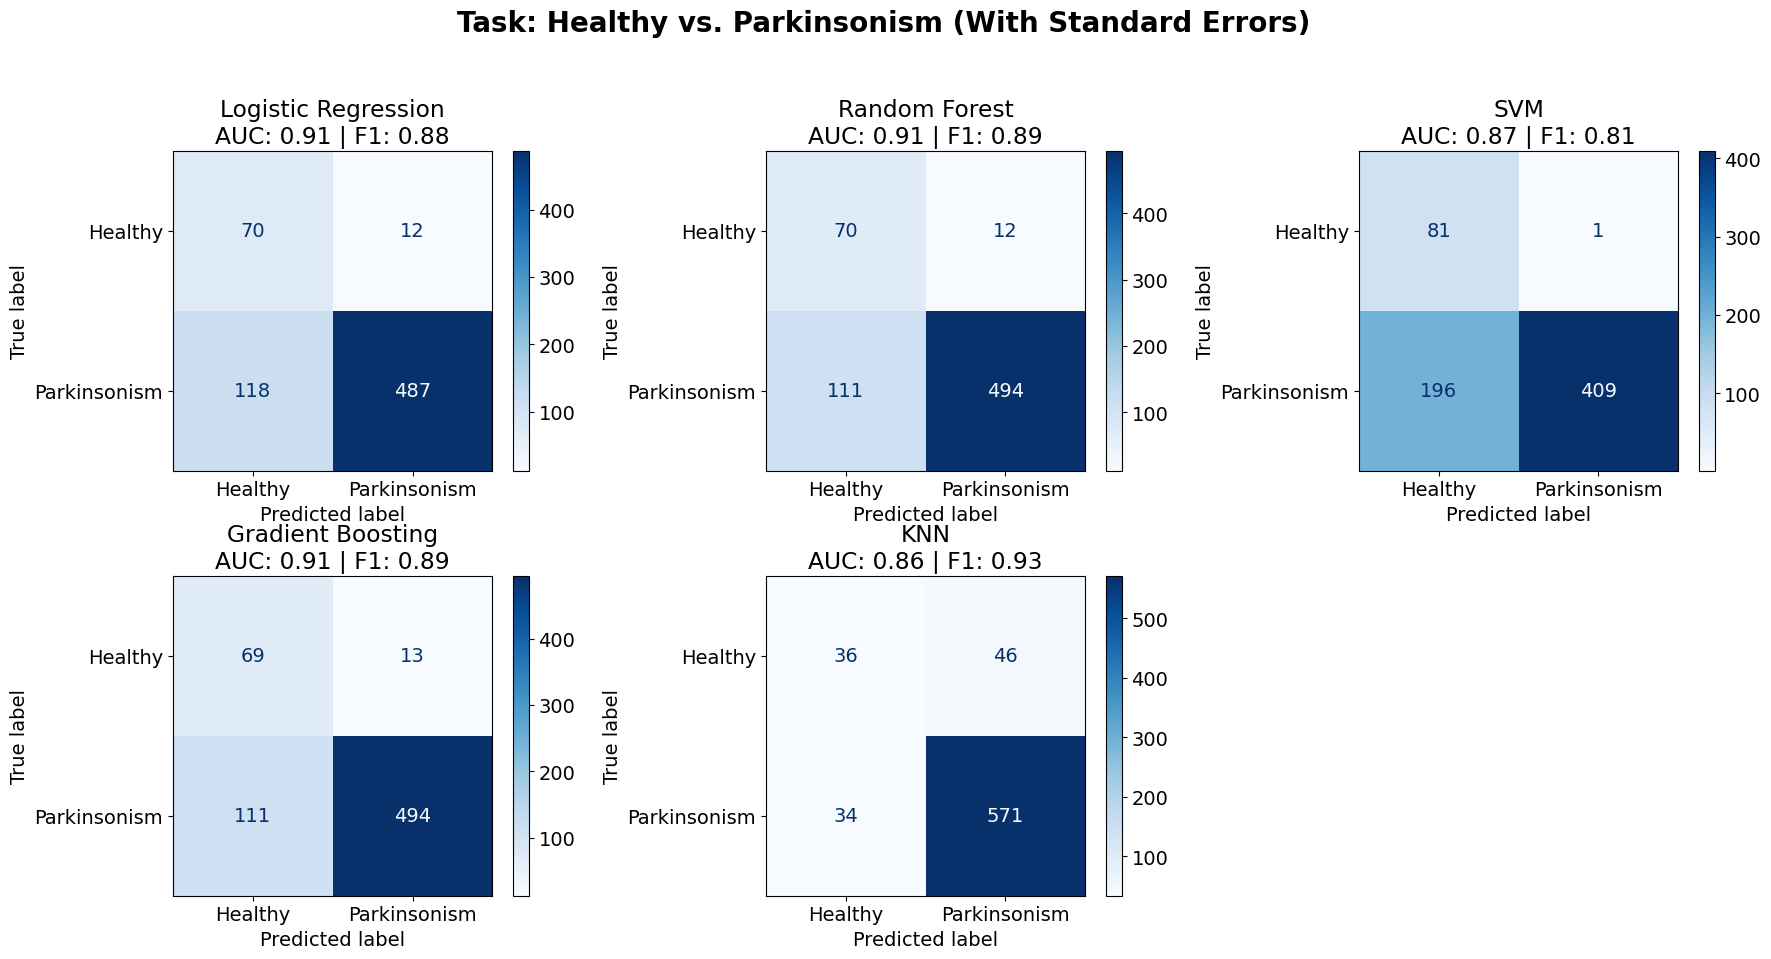


Summary Metrics (Mean ± SE):
                 Model     Sensitivity     Specificity             PPV  \
0  Logistic Regression  0.805 (±0.016)  0.854 (±0.039)  0.976 (±0.007)   
1        Random Forest  0.817 (±0.016)  0.854 (±0.039)  0.976 (±0.007)   
2                  SVM  0.676 (±0.019)  0.988 (±0.012)  0.998 (±0.002)   
3    Gradient Boosting  0.817 (±0.016)  0.841 (±0.040)  0.974 (±0.007)   
4                  KNN  0.944 (±0.009)  0.439 (±0.055)  0.925 (±0.011)   

              NPV        F1-Score   C-Index (AUC)  
0  0.372 (±0.035)  0.882 (±0.012)  0.908 (±0.012)  
1  0.387 (±0.036)  0.889 (±0.012)  0.912 (±0.012)  
2  0.292 (±0.027)  0.806 (±0.015)  0.873 (±0.015)  
3  0.383 (±0.036)  0.888 (±0.012)  0.908 (±0.012)  
4  0.514 (±0.060)  0.935 (±0.009)  0.858 (±0.017)  

--- Starting Task 2: PD vs. PD Plus ---
Finished Tuning: Logistic Regression
Finished Tuning: Random Forest
Finished Tuning: SVM
Finished Tuning: Gradient Boosting
Finished Tuning: KNN


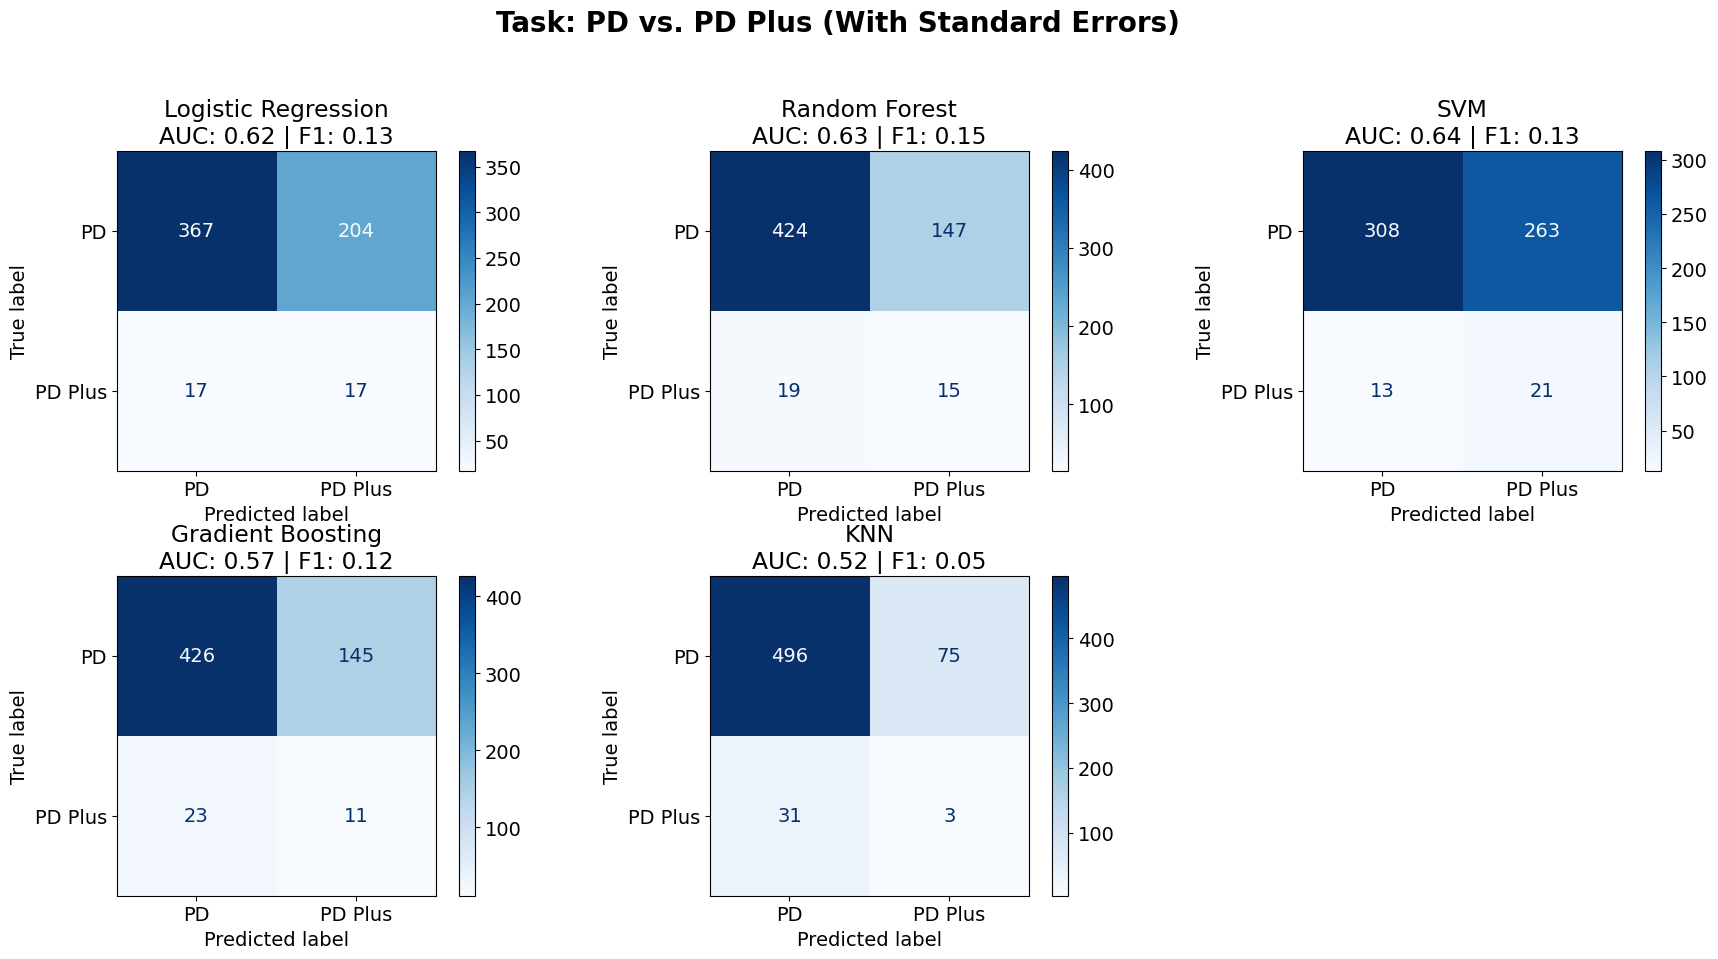


Summary Metrics (Mean ± SE):
                 Model     Sensitivity     Specificity             PPV  \
0  Logistic Regression  0.500 (±0.086)  0.643 (±0.020)  0.077 (±0.018)   
1        Random Forest  0.441 (±0.085)  0.743 (±0.018)  0.093 (±0.023)   
2                  SVM  0.618 (±0.083)  0.539 (±0.021)  0.074 (±0.016)   
3    Gradient Boosting  0.324 (±0.080)  0.746 (±0.018)  0.071 (±0.020)   
4                  KNN  0.088 (±0.049)  0.869 (±0.014)  0.038 (±0.022)   

              NPV        F1-Score   C-Index (AUC)  
0  0.956 (±0.010)  0.133 (±0.014)  0.616 (±0.053)  
1  0.957 (±0.010)  0.153 (±0.015)  0.633 (±0.053)  
2  0.960 (±0.011)  0.132 (±0.014)  0.638 (±0.053)  
3  0.949 (±0.010)  0.116 (±0.013)  0.570 (±0.052)  
4  0.941 (±0.010)  0.054 (±0.009)  0.517 (±0.051)  


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay, roc_auc_score, confusion_matrix, f1_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- helper function for Standard Errors ---
def calculate_se_proportion(p, n):
    if n <= 0: return 0
    # Capped at 0/1 to avoid imaginary numbers if p is slightly outside [0,1] due to float precision
    return np.sqrt((p * (1 - p)) / n)

def calculate_auc_se(auc, n_pos, n_neg):
    """Hanley and McNeil estimation for AUC Standard Error"""
    if n_pos == 0 or n_neg == 0: return 0
    q1 = auc / (2 - auc)
    q2 = (2 * auc**2) / (1 + auc)
    term1 = auc * (1 - auc)
    term2 = (n_pos - 1) * (q1 - auc**2)
    term3 = (n_neg - 1) * (q2 - auc**2)
    return np.sqrt((term1 + term2 + term3) / (n_pos * n_neg))


# --- 2. PREPROCESSING PIPELINES ---
num_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

# --- 3. MODEL & HYPERPARAMETER DEFINITIONS ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

param_grids = {
    "Logistic Regression": {'clf__C': [0.1, 1, 10]},
    "Random Forest": {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 10]},
    "SVM": {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale']},
    "Gradient Boosting": {'clf__learning_rate': [0.01, 0.1], 'clf__max_iter': [100, 200]},
    "KNN": {'clf__n_neighbors': [3, 5, 10], 'clf__weights': ['uniform', 'distance']}
}

# --- 4. THE EXECUTION ENGINE ---
def run_binary_classification(X_data, y_data, title, class_names):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, stratify=y_data, random_state=42
    )
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Task: {title} (With Standard Errors)', fontsize=20, fontweight='bold')
    axes = axes.flatten()

    results_table = []

    for i, (name, clf) in enumerate(models.items()):
        pipeline = ImbPipeline(steps=[
            ('pre', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('clf', clf)
        ])
        
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=skf,
            scoring='roc_auc',
            n_jobs=-1
        )
        
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        
        # Confusion Matrix elements
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        # Calculate Metrics
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
        auc  = roc_auc_score(y_test, y_proba)
        f1   = f1_score(y_test, y_pred)
        
        # Calculate Standard Errors
        se_sens = calculate_se_proportion(sens, (tp + fn))
        se_spec = calculate_se_proportion(spec, (tn + fp))
        se_ppv  = calculate_se_proportion(ppv, (tp + fp))
        se_npv  = calculate_se_proportion(npv, (tn + fn))
        se_f1   = calculate_se_proportion(f1, len(y_test)) # SE for F1 over total test set
        se_auc  = calculate_auc_se(auc, sum(y_test==1), sum(y_test==0))
        
        results_table.append({
            "Model": name,
            "Sensitivity": f"{sens:.3f} (±{se_sens:.3f})",
            "Specificity": f"{spec:.3f} (±{se_spec:.3f})",
            "PPV": f"{ppv:.3f} (±{se_ppv:.3f})",
            "NPV": f"{npv:.3f} (±{se_npv:.3f})",
            "F1-Score": f"{f1:.3f} (±{se_f1:.3f})",
            "C-Index (AUC)": f"{auc:.3f} (±{se_auc:.3f})",
            "Best_Model_Object": best_model
        })

        print(f"Finished Tuning: {name}")
        
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, 
            display_labels=class_names, 
            cmap='Blues', 
            ax=axes[i]
        )
        axes[i].set_title(f"{name}\nAUC: {auc:.2f} | F1: {f1:.2f}")

    # Remove unused subplots
    if len(models) < len(axes):
        for j in range(len(models), len(axes)):
            fig.delaxes(axes[j])
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return pd.DataFrame(results_table)

# --- 5. EXECUTION ---

print("\n--- Starting Task 1: Healthy vs. Parkinsonism ---")
results_p1 = run_binary_classification(X1, y1, "Healthy vs. Parkinsonism", ["Healthy", "Parkinsonism"])
print("\nSummary Metrics (Mean ± SE):")
print(results_p1.drop(columns="Best_Model_Object")) # Drop object for cleaner print

print("\n--- Starting Task 2: PD vs. PD Plus ---")
results_p2 = run_binary_classification(X2, y2, "PD vs. PD Plus", ["PD", "PD Plus"])
print("\nSummary Metrics (Mean ± SE):")
print(results_p2.drop(columns="Best_Model_Object"))

In [16]:
print(results_p1[['Model', 'Sensitivity', 'Specificity', 'C-Index']].round(3).T)

print(results_p2[['Model', 'Sensitivity', 'Specificity', 'C-Index']].round(3).T)


                               0              1      2                  3  \
Model        Logistic Regression  Random Forest    SVM  Gradient Boosting   
Sensitivity                0.805          0.825  0.807              0.836   
Specificity                0.854          0.854  0.854              0.841   
C-Index                    0.909          0.918  0.895              0.918   

                 4  
Model          KNN  
Sensitivity  0.954  
Specificity  0.463  
C-Index      0.865  
                               0              1      2                  3  \
Model        Logistic Regression  Random Forest    SVM  Gradient Boosting   
Sensitivity                  0.5          0.382  0.676              0.382   
Specificity                0.655          0.779  0.536              0.769   
C-Index                    0.679          0.669  0.657              0.675   

                 4  
Model          KNN  
Sensitivity  0.206  
Specificity  0.879  
C-Index      0.589  


##Hyperparameter Tuning

In [40]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# --- 1. Define Parameter Grids for each model ---
# Use the prefix 'clf__' to refer to the model parameters in the pipeline
param_grids = {
    "Logistic Regression": {
        'clf__C': [0.1, 1, 10],
        'clf__penalty': ['l2']
    },
    "Random Forest": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    "SVM": {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear']
    },
    "Gradient Boosting": {
        'clf__learning_rate': [0.01, 0.1],
        'clf__max_iter': [100, 200]
    },
    "KNN": {
        # Test a wider range of neighbors (odd numbers prevent ties)
        'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21,25,31,33,35,41,51],

        # 'uniform' treats all neighbors the same;
        # 'distance' gives more weight to closer (more similar) patients
        'clf__weights': ['uniform', 'distance'],

        # 'euclidean' is straight-line distance;
        # 'manhattan' is often better when you have many different clinical scores
        'clf__metric': ['euclidean', 'manhattan']
    }
}

best_models = {}

print("Starting Hyperparameter Tuning...")

for name, clf in models.items():
    # Build the same pipeline structure you used in CV
    pipeline = ImbPipeline(steps=[
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])

    # Initialize GridSearch
    # 'scoring' can be set to 'f1_macro' to match your previous criteria
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)

    # Store the best model and parameters
    best_models[name] = grid_search.best_estimator_

    print(f"\nBEST FOR {name}:")
    print(f" Parameters: {grid_search.best_params_}")
    print(f" Best CV Macro F1: {grid_search.best_score_:.3f}")

    # Final evaluation on the hidden test set
    y_pred = best_models[name].predict(X_test)
    print(f" Test Set Performance for {name}:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin


BEST FOR Logistic Regression:
 Parameters: {'clf__C': 10, 'clf__penalty': 'l2'}
 Best CV Macro F1: 0.463
 Test Set Performance for Logistic Regression:
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.12      0.44      0.19        34
                           Healthy control/Contrôle       0.45      0.93      0.60        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.95      0.65      0.77       571

                                           accuracy                           0.68       687
                                          macro avg       0.51      0.67      0.52       687
                                       weighted avg       0.85      0.68      0.72       687

Fitting 5 folds for each of 12 candidates, totalling 60 fits

BEST FOR Random Forest:
 Parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
 Best CV Macro F

KeyboardInterrupt: 

From the tuning, the winner is KNN with accuracy of 0.78

In [8]:
##Optimization (KNN Specialization)
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# Keep the RobustScaler (it's better for clinical scores)
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), numeric_features),
    ('cat', cat_transformer, categorical_features)
])

param_grids = {
    "KNN": {
        # Searching around your best performing k-values
        'clf__n_neighbors': [15, 21, 27, 33, 35,41,51],
        'clf__weights': ['distance'],
        'clf__metric': ['manhattan'],

        # 'None' means use all original features (No PCA)
        # We also test higher component counts
        'pca__n_components': [None, 12, 14, 16]
    }
}

for name, clf in models.items():
    if name == "KNN":
        pipeline = ImbPipeline(steps=[
            ('pre', preprocessor),
            ('pca', PCA()),
            ('smote', SMOTE(random_state=42)),
            ('clf', clf)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=skf,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_

        print(f"\nFINAL PEAK TUNING FOR {name}:")
        print(f" Best Parameters: {grid_search.best_params_}")

        y_pred = best_models[name].predict(X_test)
        print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 28 candidates, totalling 140 fits

FINAL PEAK TUNING FOR KNN:
 Best Parameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 33, 'clf__weights': 'distance', 'pca__n_components': None}
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.12      0.41      0.18        34
                           Healthy control/Contrôle       0.71      0.55      0.62        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.89      0.79      0.84       571

                                           accuracy                           0.74       687
                                          macro avg       0.58      0.58      0.55       687
                                       weighted avg       0.83      0.74      0.78       687



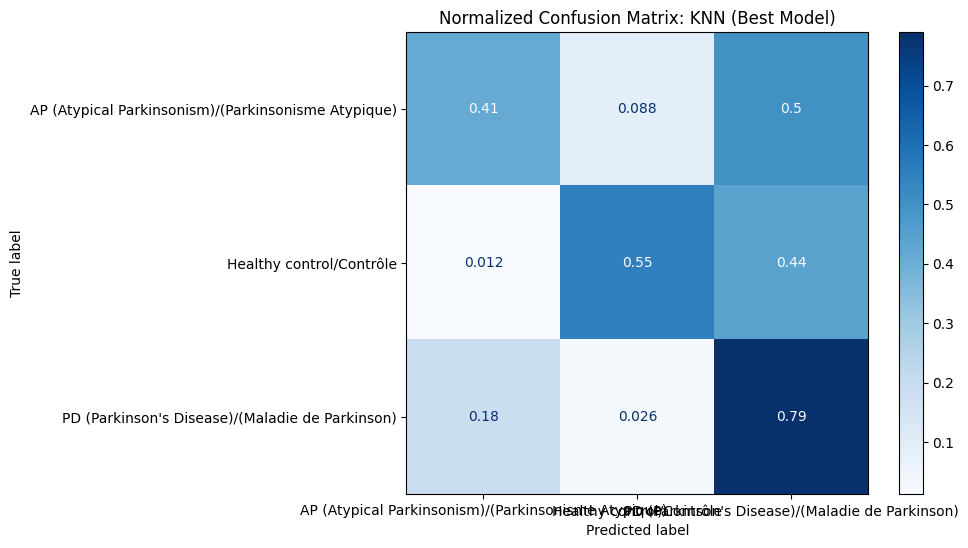


--- Summary Table ---
                 Model  Test Accuracy  Macro F1-Score  AP Recall (Sensitivity)
0  Logistic Regression           0.65            0.50                     0.38
1        Random Forest           0.73            0.52                     0.21
2                  SVM           0.65            0.49                     0.35
3    Gradient Boosting           0.72            0.52                     0.26
4                  KNN           0.77            0.56                     0.41


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_92273/3979978891.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Macro F1-Score", data=df_results, palette="viridis")


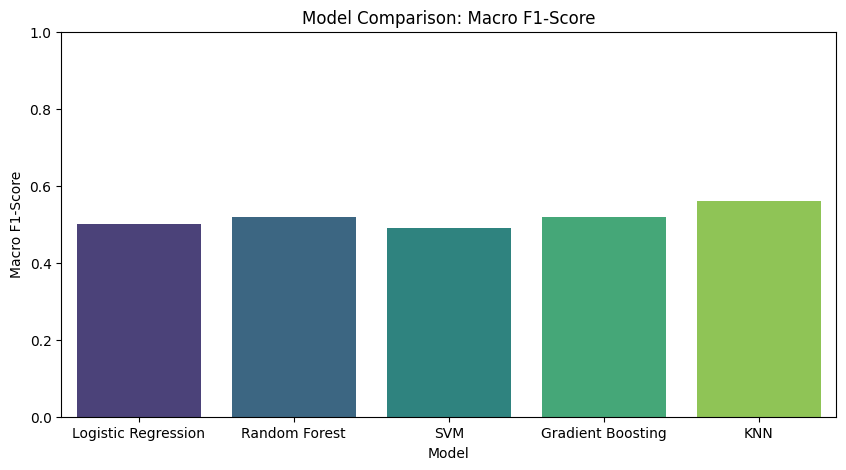

In [9]:
##Final Analysis (The Results)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Confusion Matrix for the Winner (KNN) ---
best_knn = best_models['KNN']
y_pred_knn = best_knn.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax,
    normalize='true' # Shows percentages
)
plt.title("Normalized Confusion Matrix: KNN (Best Model)")
plt.show()

# --- 2. Summary Table of Model Performance ---
results_data = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "Gradient Boosting", "KNN"],
    "Test Accuracy": [0.65, 0.73, 0.65, 0.72, 0.77],
    "Macro F1-Score": [0.50, 0.52, 0.49, 0.52, 0.56],
    "AP Recall (Sensitivity)": [0.38, 0.21, 0.35, 0.26, 0.41]
}

df_results = pd.DataFrame(results_data)
print("\n--- Summary Table ---")
print(df_results)

# Plotting the comparison
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Macro F1-Score", data=df_results, palette="viridis")
plt.ylim(0, 1)
plt.title("Model Comparison: Macro F1-Score")
plt.show()


--- SHAP Summary Plot: Healthy vs. Parkinsonism ---


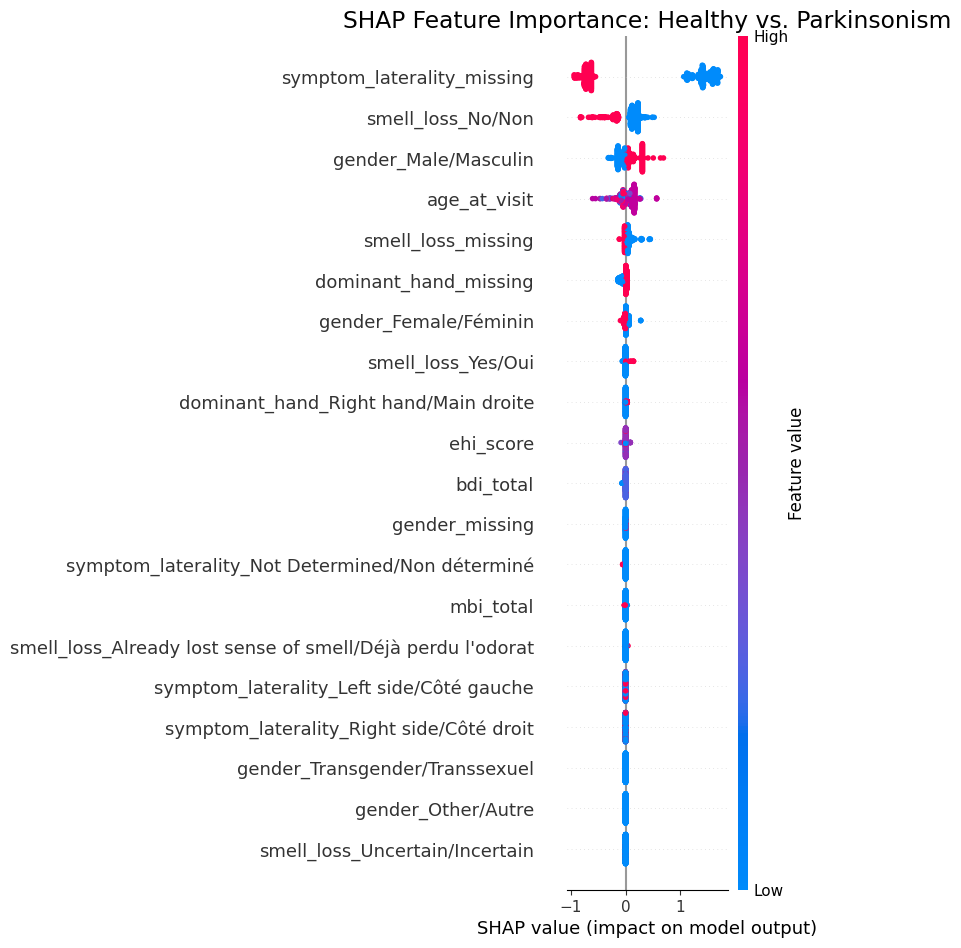


--- SHAP Summary Plot: PD vs. PD Plus ---


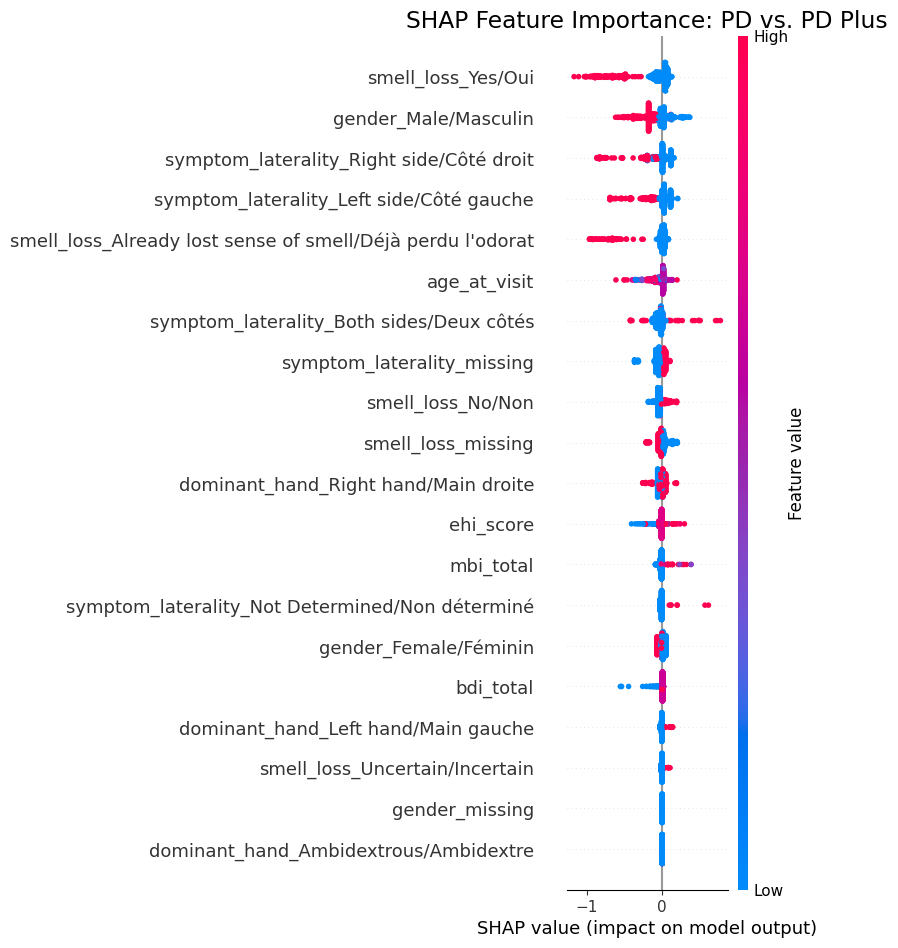

In [54]:
import shap

def produce_shap_plots(X_data, y_data, results_df, task_title):
    """
    X_data: Original dataframe (before preprocessing)
    y_data: Target labels
    results_df: The dataframe returned by run_binary_classification
    task_title: String for plot title
    """
    
    # 1. Re-split to get the training data (same random_state as your engine)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, stratify=y_data, random_state=42
    )

    # 2. Extract the Gradient Boosting pipeline (manually or from your models dict)
    # For this example, we assume we are using the best estimator found during the run
    # Note: Replace 'Gradient Boosting' with the exact key used in your models dict
    
    # Let's recreate the best pipeline for GB specifically to ensure we have the transformer
    # In a real scenario, you'd pull this from your grid_search.best_estimator_
    gb_pipeline = results_df.loc[results_df['Model'] == 'Gradient Boosting', 'Best_Model_Object'].values[0]
    
    # 3. Transform the data
    # SHAP needs the numerical representation of the data after Preprocessing
    preprocessor = gb_pipeline.named_steps['pre']
    X_test_transformed = preprocessor.transform(X_test)
    
    # Get feature names after OneHotEncoding
    cat_features_transformed = preprocessor.named_transformers_['cat']\
                                .named_steps['ohe']\
                                .get_feature_names_out(categorical_features)
    feature_names = np.concatenate([numeric_features, cat_features_transformed])

    # 4. Initialize SHAP Explainer
    # HistGradientBoosting is compatible with TreeExplainer or KernelExplainer
    # We use the underlying model (the 'clf' step)
    model = gb_pipeline.named_steps['clf']
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_transformed)

    # 5. Plotting
    print(f"\n--- SHAP Summary Plot: {task_title} ---")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
    plt.title(f"SHAP Feature Importance: {task_title}")
    plt.show()

# --- EXECUTION ---

# Produce plots for Task 1
produce_shap_plots(X1, y1, results_p1, "Healthy vs. Parkinsonism")

# Produce plots for Task 2
produce_shap_plots(X2, y2, results_p2, "PD vs. PD Plus")

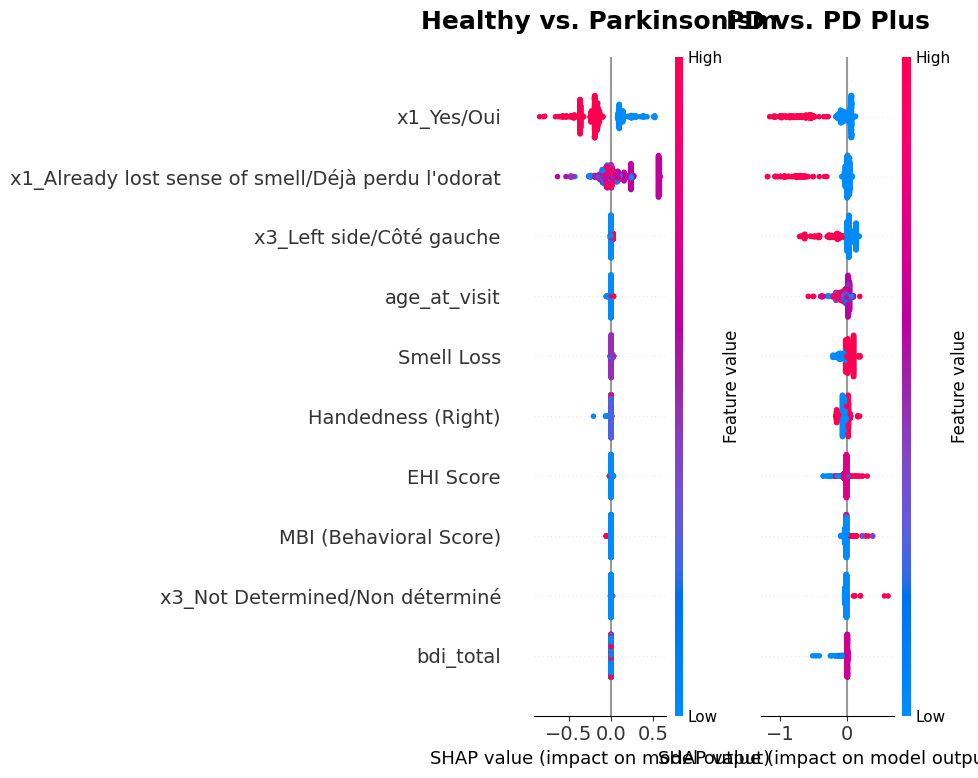

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

def produce_final_shap_plots(X1, y1, res1, X2, y2, res2):
    """
    Creates side-by-side SHAP plots with increased font sizes 
    and a significantly narrower figure width.
    """
    
    # 1. Update Global Font Settings
    plt.rcParams.update({'font.size': 14}) # Increase general font size
    
    clean_map = {
        'BDI (Depression)': 'BDI (Depression)',
        'x2_Right hand/Main droite': 'Handedness (Right)',
        'EHI (Handedness Score)': 'EHI (Handedness Score)',
        'ehi_score': 'EHI Score',
        'Age at Visit': 'Age at Visit',
        'x1_No/Non': 'Smell Loss', 
        'Age at Diagnosis': 'Age at Diagnosis',
        'Disease Duration': 'Disease Duration',
        'moca_total': 'MoCA (Cognitive Score)',
        'mbi_total': 'MBI (Behavioral Score)',
        'diease_duration': 'Disease Duration',

    }

    def get_task_shap_data(X_data, y_data, results_df):
        _, X_test, _, _ = train_test_split(
            X_data, y_data, test_size=0.20, stratify=y_data, random_state=42
        )
        
        gb_pipeline = results_df.loc[results_df['Model'] == 'Gradient Boosting', 'Best_Model_Object'].values[0]
        preprocessor = gb_pipeline.named_steps['pre']
        model = gb_pipeline.named_steps['clf']
        
        X_transformed = preprocessor.transform(X_test)
        cat_ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
        feature_names_out = np.concatenate([numeric_features, cat_ohe.get_feature_names_out()])
        
        X_df = pd.DataFrame(X_transformed, columns=feature_names_out)
        
        # Reverse Smell Logic
        if 'x1_No/Non' in X_df.columns:
            X_df['x1_No/Non'] = 1 - X_df['x1_No/Non']
            
        X_df = X_df.rename(columns=clean_map)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_df)
        
        return X_df, shap_values

    # 2. Get data for both tasks
    X_df1, shap1 = get_task_shap_data(X1, y1, res1)
    X_df2, shap2 = get_task_shap_data(X2, y2, res2)

    # 3. Selection Logic (Exclude Gender Male and Missing)
    top_idx = np.abs(shap1).mean(0).argsort()[::-1]
    all_features = X_df1.columns
    top_10_features = []
    excluded_keywords = ["missing", "male", "masculin"]
    
    for i in top_idx:
        feat_name = all_features[i]
        if not any(word in feat_name.lower() for word in excluded_keywords):
            if len(top_10_features) < 10:
                top_10_features.append(feat_name)

    # Filter DFs and SHAP arrays
    X_df1_filt = X_df1[top_10_features]
    X_df2_filt = X_df2[top_10_features]
    indices = [X_df1.columns.get_loc(f) for f in top_10_features]
    shap1_filt = shap1[:, indices]
    shap2_filt = shap2[:, indices]

    # 4. Narrow Plotting with Big Text
    # Reduced width from 20 to 10 to make it half as wide
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

    # Plot Task 1
    plt.sca(ax1)
    shap.summary_plot(shap1_filt, X_df1_filt, show=False, plot_size=None)
    ax1.set_title("Healthy vs. Parkinsonism", fontsize=18, fontweight='bold', pad=20)
    ax1.tick_params(axis='both', which='major', labelsize=14)

    # Plot Task 2
    plt.sca(ax2)
    shap.summary_plot(shap2_filt, X_df2_filt, show=False, plot_size=None)
    ax2.set_title("PD vs. PD Plus", fontsize=18, fontweight='bold', pad=20)
    ax2.set_ylabel("") # Shared variable names on the left only
    ax2.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()
    plt.show()

# Run visualization
produce_final_shap_plots(X1, y1, results_p1, X2, y2, results_p2)